Let's analyze whether different spurious correlation methods affect the importance of spurious features in the representation.

We have models pretrained with:
* ERM
* Reweighting
* Group DRO
* Just Train Twice (JTT)
* Deep Feature Reweighting (DFR)


We will do, for each model: 
1. Decompose training data into PCA components.
2. Evaluate each component in terms of how much it can predict the spurious label.
Prediction is done by training a LogisticRegression on the decomposition for each component for T iterations.
3. Note components which have over X% accuracy in predicting the spurious label.
4. Note where in the representation top predicting components belong




In [3]:
import numpy as np
import sys
sys.path.append("/workspace1/araymond/svdrop/")
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score
from collections import defaultdict
from easydict import EasyDict as edict
from utils import SimpleCNN, SVDropClassifier
from torch.utils.data import DataLoader
from copy import deepcopy
import torch.nn as nn
import torch
import torchvision
import os
from tqdm.notebook import tqdm
import pandas as pd
from data.data import prepare_data
cub_dict = {0.0: 50, 0.25: 625, 0.5: 75, 0.75: 875, 0.9: 95, 1.0: 100}
def setup(model, dataset , dataset_corr):
    args = edict()
    args.dataset = dataset
    args.root_dir = "/workspace1/araymond/datasets"
    if dataset == "MNISTCIFAR":
        args.target_name = f"waterbird_complete{dataset_corr}"
        args.confounder_names = [dataset_corr]
        args.fraction = 1.0
    elif dataset =="CelebA":
        args.target_name = f"Blond_Hair"
        args.confounder_names = ["Male"]
        args.fraction = 0.1
    else:
        args.target_name = f"waterbird_complete{cub_dict[dataset_corr]}"
        args.confounder_names = ["forest2water2"]
        args.fraction = 1.0
    args.model = model
    args.augment_data = None
    args.shift_type = "confounder"
    args.metadata_csv_name = 'metadata.csv'

    return args

def get_reps(model, dl, device="cuda",remove="none"):
    temp_model = deepcopy(model).to(device)
    temp_model.fc = nn.Identity()
    results = None

    with torch.no_grad():
        for x, y, g, *_ in tqdm(dl, desc="Reps"):
            print("1-Getting data")
            x = x.to(device)
            if remove == "spur":
                x[:,:,32:,:]*=0
            elif remove == "nonspur":
                x[:,:,:32,:]*=0
                #print(x.shape, x.max(),x.min
            print("2-Forward")
            reps = temp_model(x).detach().cpu()
            g = g % 2
            print("3-Appending Results")
            if results is None:
                results = reps
                y_label = y
                y_spur = g
            else:  
                results = torch.cat([results, reps], dim=0)
                y_label = torch.cat([y_label,y], dim=0)
                y_spur = torch.cat([y_spur,g], dim=0)
            print("4-Done")
        return results, y_label, y_spur

def train_regression(x_train, x_test, y_train, y_test):
        x_train = x_train.cpu()
        y_train = y_train.cpu()
        x_test = x_test.cpu()
        y_test = y_test.cpu()
        # Create a logistic regression model
        model = LogisticRegression(max_iter=1000)
        # Train the model on the training set
        model.fit(x_train, y_train)  # ravel() is used to convert y_train to a 1D array
        # Make predictions on the test set
        y_pred = model.predict(x_train)
        y_pred_test = model.predict(x_test)
        # Calculate accuracy
        train_acc = accuracy_score(y_train, y_pred)
        test_acc = accuracy_score(y_test, y_pred_test)
        return {'train': train_acc, 'test': test_acc}
    
def train_linear_regression(x_train,x_test, y_train, y_test):
        x_train = x_train.cpu()
        y_train = y_train.cpu()
        x_test = x_test.cpu()
        y_test = y_test.cpu()
        # Create a logistic regression model
        model = LinearRegression()
        # Train the model on the training set
        model.fit(x_train, y_train)  # ravel() is used to convert y_train to a 1D array
        # Make predictions on the test set
        y_pred = model.predict(x_train)
        y_pred_test = model.predict(x_test)
        # Calculate accuracy
        r2 = r2_score(y_train, y_pred)
        r2_test = r2_score(y_test, y_pred_test)
        slope = model.coef_[0]
        intercept = model.intercept_
        
        return {'train':r2,
                'test': r2_test,
                'slope': model.coef_[0],
                'bias': model.intercept_} 
    
def spurious_performance(D_train, D_test, y_train, y_test):
    n_dims = D_train.shape[1]
    report = {'dim': [], 'train_acc': [], 'test_acc': []}
    for dim in range(n_dims):
        x_train = D_train[:, dim]
        x_test = D_test[:, dim]
        x_train = x_train.view(-1,1)
        x_test = x_test.view(-1,1)
        #y_train = y_train.view(-1,1)
        #y_test = y_test.view(-1,1)
        r = train_regression(x_train, x_test, y_train, y_test)
        report['dim'].append(dim)
        report['train_acc'].append(r['train'])
        report['test_acc'].append(r['test'])
    return report

def get_dataloaders(dataset, dataset_corr):
    train_loader = dro_dataset.get_loader(train_data,
                                          train=True,
                                          reweight_groups=args.reweight_groups,
                                          **loader_kwargs)

    val_loader = dro_dataset.get_loader(val_data,
                                        train=False,
                                        reweight_groups=None,
                                        **loader_kwargs)

def load_model(dataset, method, model_corr, seed=111):
    # To get to model path is:
    # {DATASET}/{METHOD}_{MODEL_CORR}/model_results_{SEED}/best_model.pth
    # Ex: MNISTCIFAR/erm_0.75/model_results_111/best_model.pth

    if dataset == "CUB":
        model_corr =  cub_dict[model_corr]
    if dataset != "CelebA":
        path = f"{dataset}/{method}_{model_corr}/model_outputs_{seed}/best_model.pth"
    else:
        path = f"{dataset}/{method}/model_outputs_{seed}/best_model.pth"
    if not os.path.exists(path): # There never was a best model!
        path = path.replace("best_model.pth", "0_model.pth")
    weights = torch.load(path)
    if dataset == "MNISTCIFAR":
        m = SimpleCNN([32,64,128],1,num_classes=2, add_pooling=False)
    else:
        m = torchvision.models.resnet50(pretrained=True)
        d = m.fc.in_features
        m.fc = SVDropClassifier(d, 2)
    
    m.load_state_dict(weights)
    return m



#m = load_model(dataset, method, model_corr)
#R_train, y_train, y_mnist = get_reps(m, dls['train'])


/home/araymond/pyenv/versions/mini/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [13]:

dataset = "CUB"
method ="erm"
model_corr = 0.9
dataset_corr = 0.9
bs = {'MNISTCIFAR':10000, 'CUB': 128, "CelebA": 1024}
#m = load_model(dataset, method, model_corr)
m = "resnet50"
args = setup(m, dataset, dataset_corr)
data = prepare_data(args, train=True)
dls = {'train': DataLoader(data[0], batch_size=bs[dataset], shuffle=False),
       'test': DataLoader(data[1], batch_size=bs[dataset], shuffle=False)}
m = load_model(dataset, method, model_corr)
R_train, y_train, y_mnist = get_reps(m, dls['train'])



Reading '/workspace1/araymond/datasets/waterbird_complete95_forest2water2/metadata.csv'


/home/araymond/pyenv/versions/mini/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/araymond/pyenv/versions/mini/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Reps:   0%|          | 0/38 [00:00<?, ?it/s]

1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting da

In [23]:
m = "resnet50"
dataset = "CelebA"
dataset_corr = 0.0
final_report = defaultdict(list)
n_dirs = 100 # analyze first 1000 directions 
model_corr = 0.0
#methods = ["jtt_3000_50","erm","reweight_rw","gdro"]
methods = ["erm","gdro"]
seed = 111
bs = {'MNISTCIFAR':10000, 'CUB': 128, "CelebA": 1024}
# 6 x 6 x 100 directions x 3 methods = 10800 results
corrs = [0.0, 0.25, 0.5, 0.75, 0.9]
#corrs = ["50", "625","75","875", "95"]
for dataset_corr in tqdm(corrs, desc="Dataset Correlations"):
    args = setup(m, dataset, dataset_corr)
    data = prepare_data(args, train=True)
    dls = {'train': DataLoader(data[0], batch_size=bs[dataset], shuffle=False),
           'test': DataLoader(data[1], batch_size=bs[dataset], shuffle=False)}
    model_corr = dataset_corr
    #for model_corr in tqdm(corrs, leave=False, desc="Model Correlations"):
    for method in tqdm(methods,leave=False, desc="Methods"): # 
        #print(f"{method}-{dataset} DS_Corr: {dataset_corr}-M_Corr:{model_corr}")
        model = load_model(dataset, method, model_corr)
        print("Getting train reps")
        R_train, _ , y_train = get_reps(model, dls['train'])
        #R_nonspur, _ , _ = get_reps(model, dls['train'], remove="spur")
        #R_spur, _ , _ = get_reps(model, dls['train'], remove="nonspur")
        print("Getting test reps")
        R_test, _ , y_test = get_reps(model, dls['test'])
        print("PCA decomposition")
        _,_, V = torch.pca_lowrank(R_train, center=True, q=n_dirs)
        print("applying Decomposition")
        D_train = R_train @ V                    # Get decompositions
        #D_nonsur = R_nonspur @ V
        D_test = R_test @ V                      # Get decompositions
        n_dims = D_train.shape[-1] # number of elements in our report
        report = spurious_performance(D_train, D_test, y_train, y_test)
        # add method, dataset and correlation to r    report['method'] = [method]*n_dimseport
        report['method'] = [method]*n_dims
        report['dataset'] = [dataset]*n_dims
        report['model_corr'] = [model_corr]*n_dims
        report['dataset_corr'] = [dataset_corr]*n_dims
        # Add current report to final overall report
        for k, v in report.items():
            final_report[k]+= v

df =  pd.DataFrame.from_dict(final_report)
df.to_csv(f"asdspurious_analysis_{dataset}.csv")    


Dataset Correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Methods:   0%|          | 0/2 [00:00<?, ?it/s]

Getting train reps


Reps:   0%|          | 0/16 [00:00<?, ?it/s]

1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
Getting test reps


...

Getting train reps


Reps:   0%|          | 0/16 [00:00<?, ?it/s]

1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
Getting test reps


Reps:   0%|          | 0/20 [00:00<?, ?it/s]

1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting data
2-Forward
3-Appending Results
4-Done
1-Getting da

In [3]:
df =  pd.DataFrame.from_dict(final_report)
df.to_csv(f"spurious_analysis_{dataset}.csv")    

In [6]:
dim = 0
x_train = D_train[:, dim]
x_test = D_test[:, dim]
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

torch.Size([4795]) torch.Size([1199]) torch.Size([4795]) torch.Size([1199])


In [24]:
df

,dim,train_acc,test_acc,method,dataset,model_corr,dataset_corr
0,0,0.683910,0.696230,erm,CelebA,0.0,0.0
1,1,0.791116,0.784215,erm,CelebA,0.0,0.0
2,2,0.640904,0.645493,erm,CelebA,0.0,0.0
3,3,0.572341,0.570494,erm,CelebA,0.0,0.0
4,4,0.609695,0.617657,erm,CelebA,0.0,0.0
...,...,...,...,...,...,...,...
995,95,0.584567,0.574269,gdro,CelebA,0.9,0.9
996,96,0.584567,0.574269,gdro,CelebA,0.9,0.9
997,97,0.584567,0.574269,gdro,CelebA,0.9,0.9
998,98,0.584567,0.574269,gdro,CelebA,0.9,0.9


In [4]:
df

,dim,train_acc,test_acc,method,dataset,model_corr,dataset_corr
0,0,0.530553,0.519600,erm,CUB,0.0,0.00
1,1,0.888425,0.884904,erm,CUB,0.0,0.00
2,2,0.587070,0.581318,erm,CUB,0.0,0.00
3,3,0.494056,0.500417,erm,CUB,0.0,0.00
4,4,0.502190,0.500417,erm,CUB,0.0,0.00
...,...,...,...,...,...,...,...
1695,95,0.565381,0.500417,rw_erm,CUB,0.0,0.25
1696,96,0.565381,0.500417,rw_erm,CUB,0.0,0.25
1697,97,0.566423,0.502085,rw_erm,CUB,0.0,0.25
1698,98,0.565381,0.500417,rw_erm,CUB,0.0,0.25


In [8]:
x_train.view(-1,1)

tensor([[ 0.4044],
        [ 0.7364],
        [-0.2259],
        ...,
        [ 0.8803],
        [-0.0345],
        [-2.5213]], device='cuda:0')

How linear is the relationship between the upper and lower part of MNIST-CIFAR?

In [37]:
import matplotlib.pyplot as plt
model = "resnet50"
dataset = "CUB"
dataset_corr = 0.0
final_report = defaultdict(list)
n_dirs = 100 # analyze first 1000 directions 
model_corr = 0.0
methods = ["erm","rw","gdro"]#,"reweight","gdro"]
seed = 111
corrs = [0.0, 0.25, 0.5, 0.75, 0.9]
# 6 x 6 x 100 directions x 3 methods = 10800 results

args = setup(model, dataset, dataset_corr)
data = prepare_data(args, train=True)
dls = {'train': DataLoader(data[0], batch_size=10000, shuffle=False),
       'test': DataLoader(data[1], batch_size=10000, shuffle=False)}

results = dict()
for model_corr in tqdm(corrs, leave=False, desc="Model Correlations"):
    for method in tqdm(methods,leave=False, desc="Methods"): # 
        #print(f"{method}-{dataset} DS_Corr: {dataset_corr}-M_Corr:{model_corr}")
        model = load_model(dataset, method, model_corr)
        R_train, _ , y_train = get_reps(model, dls['train'], remove="none")
        R_nonspur, _ , _ = get_reps(model, dls['train'], remove="spur")
        R_spur, _ , _ = get_reps(model, dls['train'], remove="nonspur")
        R_test, _ , y_test = get_reps(model, dls['test'], remove="none")
        R_nonspur_test, _ , _ = get_reps(model, dls['test'], remove="spur")
        R_spur_test, _ , _ = get_reps(model, dls['test'], remove="nonspur")
        # Train a Linear Regression from R_nonspur and R_spur and try to predict R_train
        x = torch.cat([R_spur, R_nonspur], dim=1)
        x_test = torch.cat([R_spur_test, R_nonspur_test], dim=1)
        r_mix = train_linear_regression(x,x_test,R_train,R_test)
        r_spur = train_linear_regression(R_train, R_test, R_spur, R_spur_test)
        r_nonspur = train_linear_regression(R_train, R_test, R_nonspur, R_nonspur_test)
        results[model_corr] = {'mix': r_mix, 'spur': r_spur, 'nonspur':r_nonspur}
        #_,_, V = torch.pca_lowrank(R_train, center=True, q=n_dirs)
        #D_train = R_train @ V                    # Get decompositions
        #D_nonspur = R_nonspur @ V
        #D_spur = R_spur @ V
        #D_test = R_test @ V                      # Get decompositions
        #n_dims = D_train.shape[-1] # number of elements in our report
        
        #delta_nonspur = (D_train - D_nonspur).abs().mean(dim=0)
        #delta_spur = (D_train - D_spur).abs().mean(dim=0)
        #fig, axs = plt.subplots(nrows=2, figsize=(25,6))

        #axs[0].bar(list(range(delta_nonspur.shape[0])),delta_nonspur.abs().cpu())
        #axs[0].set_title(f"Minus Non Spur: {method}-{model_corr}")
        #axs[1].bar(list(range(delta_spur.shape[0])),delta_spur.abs().cpu())
        #axs[1].set_title(f"Minus Spur: {method}-{model_corr}")
        

Model Correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

## How distributed are the spurious features along singular vector dimensions?

Model Correlations:   0%|          | 0/1 [00:00<?, ?it/s]

Methods: 0it [00:00, ?it/s]

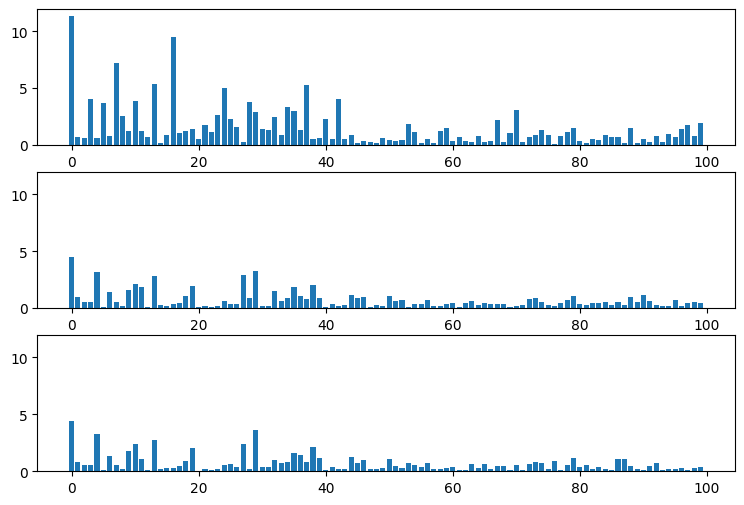

In [20]:
import matplotlib.pyplot as plt

dataset_corr = 0.0
final_report = defaultdict(list)
n_dirs = 100 # analyze first 1000 directions 
model_corr = 0.0
methods = ["erm","rw_erm","gdro"]#,"reweight","gdro"]
seed = 111
corrs = [ 0.9]
# 6 x 6 x 100 directions x 3 methods = 10800 results
for model, dataset in [('scnn','MNISTCIFAR')]:#,('resnet50','CUB')]:
    #model = "resnet50"
    #dataset = "CUB"
    args = setup(model, dataset, dataset_corr)
    data = prepare_data(args, train=True)
    bss = {'MNISTCIFAR':10000,'CUB':128}
    dls = {'train': DataLoader(data[0], batch_size=bss[dataset], shuffle=False),
           'test': DataLoader(data[1], batch_size=bss[dataset], shuffle=False)}

    results = dict()
    for model_corr in tqdm(corrs, leave=False, desc="Model Correlations"):
        fig, axs = plt.subplots(nrows=len(methods), figsize=(9,6),sharey="col")
        for i, method in tqdm(enumerate(methods),leave=False, desc="Methods"): # 
            #print(f"{method}-{dataset} DS_Corr: {dataset_corr}-M_Corr:{model_corr}")
            model = load_model(dataset, method, model_corr)
            R_train, _ , y_train = get_reps(model, dls['train'], remove="none")
            R_nonspur, _ , _ = get_reps(model, dls['train'], remove="spur")
            R_spur, _ , _ = get_reps(model, dls['train'], remove="nonspur")
            R_test, _ , y_test = get_reps(model, dls['test'], remove="none")
            R_nonspur_test, _ , _ = get_reps(model, dls['test'], remove="spur")
            R_spur_test, _ , _ = get_reps(model, dls['test'], remove="nonspur")
            # Train a Linear Regression from R_nonspur and R_spur and try to predict R_train
            x = torch.cat([R_spur, R_nonspur], dim=1)
            x_test = torch.cat([R_spur_test, R_nonspur_test], dim=1)
            #r_mix = train_linear_regression(x,x_test,R_train,R_test)
            #r_spur = train_linear_regression(R_train, R_test, R_spur, R_spur_test)
            #r_nonspur = train_linear_regression(R_train, R_test, R_nonspur, R_nonspur_test)
            #results[model_corr] = {'mix': r_mix, 'spur': r_spur, 'nonspur':r_nonspur}
            _,_, V = torch.pca_lowrank(R_train, center=True, q=n_dirs)
            D_train = R_train @ V                    # Get decompositions
            D_nonspur = R_nonspur @ V
            D_spur = R_spur @ V
            #D_test = R_test @ V                      # Get decompositions
            #n_dims = D_train.shape[-1] # number of elements in our report

            delta_nonspur = (D_train - D_nonspur).abs().mean(dim=0)
            delta_spur = (D_train - D_spur).abs().mean(dim=0)


            axs[i].bar(list(range(delta_nonspur.shape[0])),delta_nonspur.abs().cpu())
            #axs[j].set_title(f"Minus Non Spur: {method}-{model_corr}")
            #axs[1].bar(list(range(delta_spur.shape[0])),delta_spur.abs().cpu())
            #axs[1].set_title(f"Minus Spur: {method}-{model_corr}")
        plt.savefig(f"{dataset}_spurious_in_vectors.png", bbox_inches="tight")

In [41]:
import matplotlib.pyplot as plt
model = "scnn"
dataset = "MNISTCIFAR"
dataset_corr = 0.0
final_report = defaultdict(list)
n_dirs = 100 # analyze first 1000 directions 
model_corr = 0.0
methods = ["erm"]#,"reweight","gdro"]
seed = 111
corrs = [0.0, 0.25, 0.5, 0.75, 0.9]
# 6 x 6 x 100 directions x 3 methods = 10800 results

args = setup(model, dataset, dataset_corr)
data = prepare_data(args, train=True)
dls = {'train': DataLoader(data[0], batch_size=10000, shuffle=False),
       'test': DataLoader(data[1], batch_size=10000, shuffle=False)}

results = dict()
for model_corr in tqdm(corrs, leave=False, desc="Model Correlations"):
    for method in tqdm(methods,leave=False, desc="Methods"): # 
        #print(f"{method}-{dataset} DS_Corr: {dataset_corr}-M_Corr:{model_corr}")
        model = load_model(dataset, method, model_corr)
        R_train, _ , y_train = get_reps(model, dls['train'], remove="none")
        R_nonspur, _ , _ = get_reps(model, dls['train'], remove="spur")
        #R_spur, _ , _ = get_reps(model, dls['train'], remove="nonspur")
        R_test, _ , y_test = get_reps(model, dls['test'], remove="none")
        R_nonspur_test, _ , _ = get_reps(model, dls['test'], remove="spur")
        #R_spur_test, _ , _ = get_reps(model, dls['test'], remove="nonspur")
        # Train a Linear Regression from R_nonspur and R_spur and try to predict R_train
        #x = torch.cat([R_spur, R_nonspur], dim=1)
        #x_test = torch.cat([R_spur_test, R_nonspur_test], dim=1)
        r = train_regression(R_nonspur,R_nonspur_test,y_train,y_test)
        results[model_corr] = r

Model Correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

In [42]:
results

{0.0: {'train': 0.647, 'test': 0.527},
 0.25: {'train': 0.6446, 'test': 0.486},
 0.5: {'train': 0.6464, 'test': 0.494},
 0.75: {'train': 0.6412, 'test': 0.52},
 0.9: {'train': 0.6341, 'test': 0.523}}

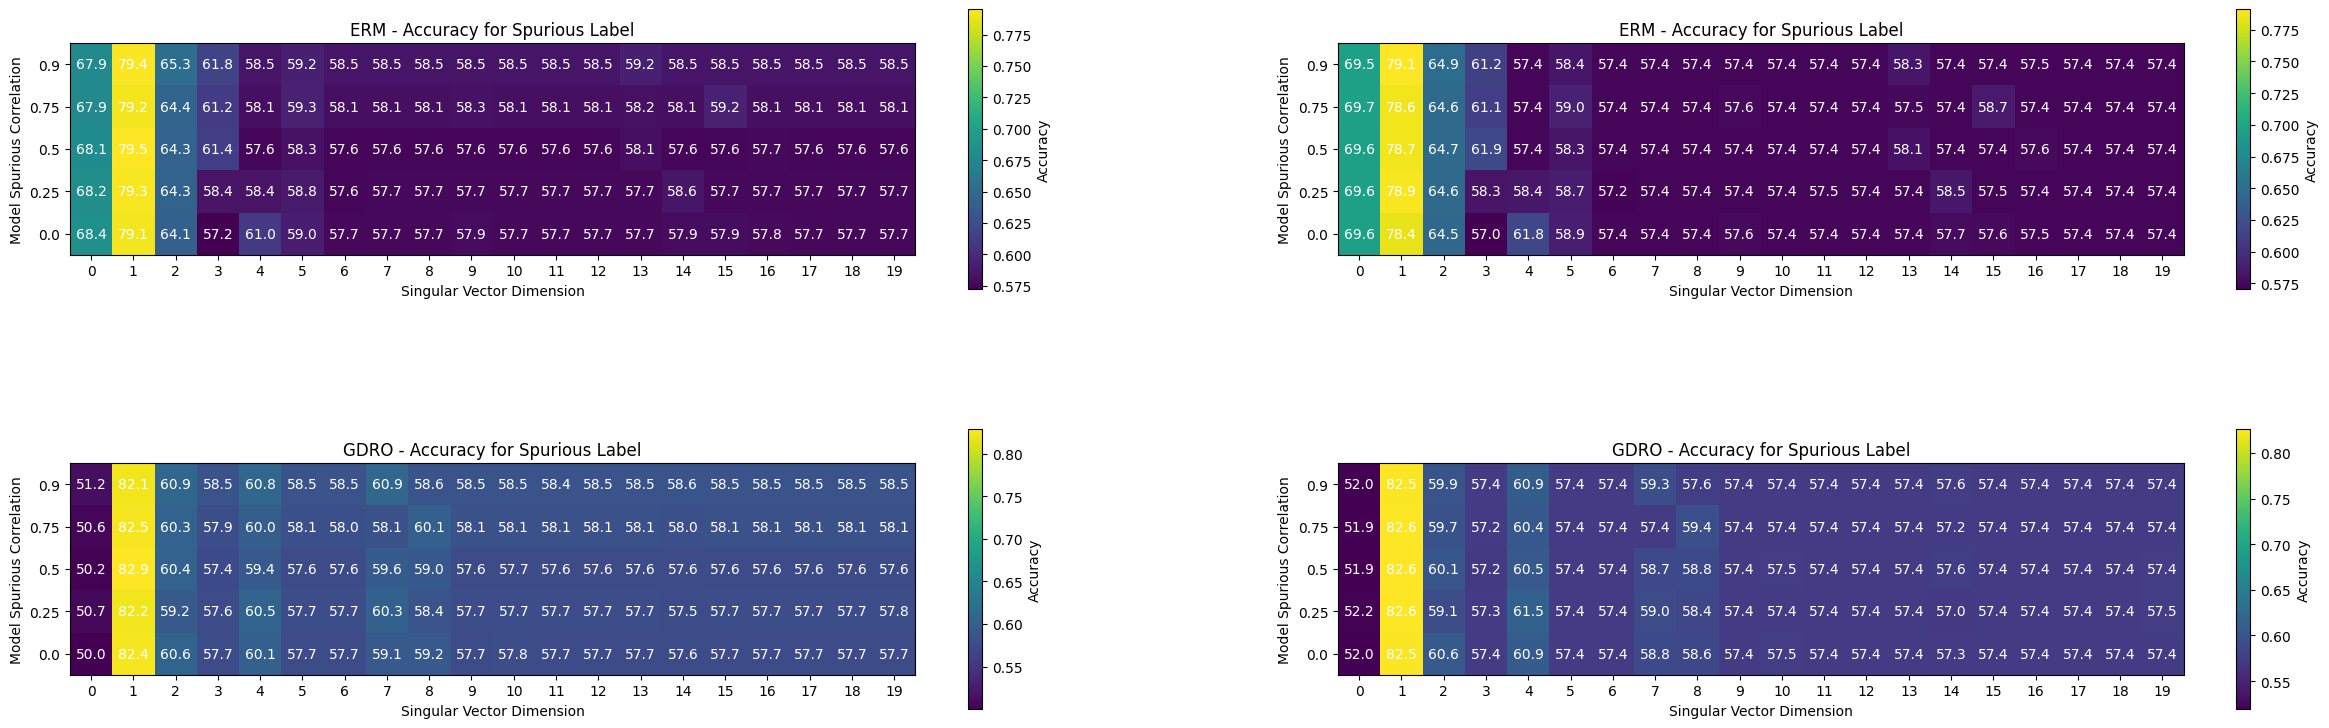

In [26]:
import matplotlib.pyplot as plt
import pandas as pd 
dataset="CelebA"
df = pd.read_csv(f"spurious_analysis_{dataset}.csv")
methods = ['erm','gdro']
#methods = ["erm","rw_erm","gdro"]
output_folder = "imgs"
fig, axs = plt.subplots(figsize=(30,5*len(methods)), ncols=2, nrows=len(methods), sharey=False, sharex=False)
for j, split in enumerate(['train','test']):
    for i, method in enumerate(methods):
        heatmap_data = df[(df['method']== method)  & (df['dim']<20)]
        heatmap_data = heatmap_data.pivot("model_corr","dim",f"{split}_acc")
        im = axs[i,j].imshow(heatmap_data, cmap='viridis', interpolation='nearest', origin='lower')
        axs[i,j].set_xlabel('Singular Vector Dimension')
        axs[i,j].set_ylabel('Model Spurious Correlation')
        axs[i,j].set_title(f'{method.upper()} - Accuracy for Spurious Label')
        # Set y-axis ticks and labels
        axs[i, j].set_yticks(range(len(heatmap_data.index)))
        axs[i, j].set_yticklabels(heatmap_data.index)

        # Add text annotations to the first subplot
        for k in range(len(heatmap_data.index)):
            for l in range(len(heatmap_data.columns)):
                axs[i,j].text(l, k, f'{100*heatmap_data.iloc[k, l]:.1f}', ha='center', va='center', color='white')
        axs[i, j].set_xticks(range(len(heatmap_data.columns)))
        axs[i, j].set_xticklabels(heatmap_data.columns)
        fig.colorbar(im, ax=axs[i,j], label='Accuracy', shrink=0.8)
# Adjust layout to prevent clipping of x-axis labels

plt.savefig(f"{dataset}_Spurious_Attributes.png", bbox_inches="tight")

In [21]:
from PIL import Image
import os
# Load your image
dataset ="MNISTCIFAR"
image_path = f"{dataset}_Spurious_Attributes.png"
image_path = f"{dataset}_spurious_in_vectors.png"
original_image = Image.open(image_path)
def split_image(original_image, rows, columns,
                caption = "spurious_accuracy",
                row_names=None,
                column_names=None,
                output_folder="output"):
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Get the dimensions of the original image
    width, height = original_image.size

    # Calculate the dimensions of each subimage
    subimage_width = width // columns
    subimage_height = height // rows

    subimages = []

    # Loop through rows and columns to create and save subimages
    for row in range(rows):
        for col in range(columns):
            left = col * subimage_width
            upper = row * subimage_height
            right = left + subimage_width
            lower = upper + subimage_height

            # Crop each subimage
            subimage = original_image.crop((left, upper, right, lower))

            # Construct subimage filename based on row and column names
            row_name = row_names[row] if row_names else f"row_{row}"
            col_name = column_names[col] if column_names else f"col_{col}"
            subimage_filename = f"{output_folder}/{caption}_{row_name}_{col_name}.png"

            # Save each subimage
            subimage.save(subimage_filename)

            subimages.append(subimage_filename)

    return subimages

split_image(original_image, 3, 1,
            caption = f"spurious_vectors_{dataset}",
            row_names=['erm',"reweight","gdro"], 
            column_names = ['train'],
            output_folder="imgs")

['imgs/spurious_vectors_MNISTCIFAR_erm_train.png',
 'imgs/spurious_vectors_MNISTCIFAR_reweight_train.png',
 'imgs/spurious_vectors_MNISTCIFAR_gdro_train.png']

In [10]:



df =  pd.DataFrame.from_dict(final_report)
df.to_csv("spurious_analysis.csv")

In [3]:
!mkdir imgs

In [104]:
# Set the option to display all rows
pd.set_option('display.max_rows', None)
df[df['dim']== 1]

,dim,train_acc,test_acc,method,dataset,model_corr,dataset_corr
1,1,0.5088,0.531,erm,MNISTCIFAR,0.00,0.00
101,1,0.5053,0.528,reweight,MNISTCIFAR,0.00,0.00
201,1,0.5093,0.532,gdro,MNISTCIFAR,0.00,0.00
301,1,0.5118,0.536,erm,MNISTCIFAR,0.25,0.00
401,1,0.5074,0.520,reweight,MNISTCIFAR,0.25,0.00
501,1,0.5125,0.530,gdro,MNISTCIFAR,0.25,0.00
601,1,0.5066,0.516,erm,MNISTCIFAR,0.50,0.00
701,1,0.5063,0.511,reweight,MNISTCIFAR,0.50,0.00
801,1,0.5063,0.520,gdro,MNISTCIFAR,0.50,0.00
901,1,0.5029,0.500,erm,MNISTCIFAR,0.75,0.00


## Check alignment!

In [19]:
import matplotlib.pyplot as plt
from torch.nn import CosineSimilarity
model = "resnet50"
dataset = "CUB"
dataset_corr = 0.0
final_report = defaultdict(list)
n_dirs = 100 # analyze first 1000 directions 
model_corr = 0.0
methods = ["erm","rw","gdro"]
seed = 111
corrs = [0.0, 0.25, 0.5, 0.75, 0.9]
# 6 x 6 x 100 directions x 3 methods = 10800 results

args = setup(model, dataset, dataset_corr)
data = prepare_data(args, train=True)
dls = {'train': DataLoader(data[0], batch_size=128, shuffle=False),
       'test': DataLoader(data[1], batch_size=128, shuffle=False)}

results = {'method': [], 'corr': [], 'cls': [], 'dim': [], 'sim': []}
sim = CosineSimilarity(dim=1)
for model_corr in tqdm(corrs, leave=False, desc="Model Correlations"):
    for method in tqdm(methods,leave=False, desc="Methods"): # 
        #print(f"{method}-{dataset} DS_Corr: {dataset_corr}-M_Corr:{model_corr}")
        model = load_model(dataset, method, model_corr)
        R_train, _ , y_train = get_reps(model, dls['train'], remove="none")
        _,_, V = torch.pca_lowrank(R_train, center=True, q=n_dirs)
        cls1 = model.fc.weight[0].detach().cuda()
        cls2 = model.fc.weight[1].detach().cuda()
        sims1 = sim(V.T, cls1)
        sims2 = sim(V.T, cls2)
        results['method'] += [method]*(2*n_dirs)
        results['corr'] += [model_corr]*(2*n_dirs)
        results['dim'] += list(range(n_dirs))
        results['cls'] += [0]*n_dirs
        results['sim'] += list(sims1.cpu())
        results['dim'] += list(range(n_dirs))
        results['cls'] += [1]*n_dirs
        results['sim'] += list(sims2.cpu())


Reading '/mnt/ialabnas/homes/araymond/investigacion/datasets/waterbird_complete50_forest2water2/metadata.csv'


Model Correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

In [23]:
df

,method,corr,cls,dim,sim
0,erm,0.0,0,0,-0.798253
1,erm,0.0,0,1,-0.075378
2,erm,0.0,0,2,0.118499
3,erm,0.0,0,3,0.019451
4,erm,0.0,0,4,-0.035958
...,...,...,...,...,...
2995,gdro,0.9,1,95,0.022890
2996,gdro,0.9,1,96,-0.012867
2997,gdro,0.9,1,97,0.006849
2998,gdro,0.9,1,98,0.005329


In [20]:
df = pd.DataFrame.from_dict(results)

In [21]:
df['sim'] = df['sim'].apply(lambda x: x.item())


,method,corr,cls,dim,sim
0,erm,0.0,0,0,-0.798253
100,erm,0.0,1,0,0.786418
200,rw,0.0,0,0,0.497281
300,rw,0.0,1,0,-0.490453
400,gdro,0.0,0,0,-0.581615
500,gdro,0.0,1,0,0.542854


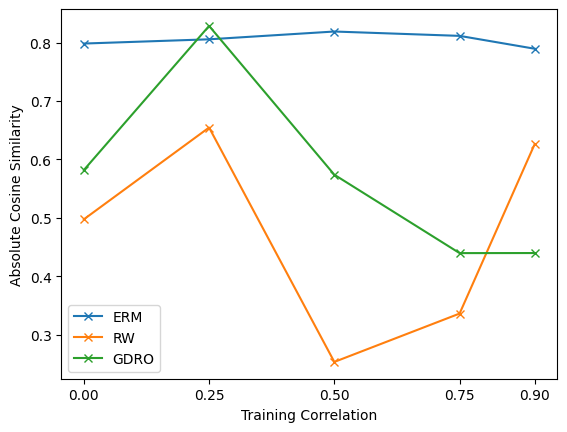

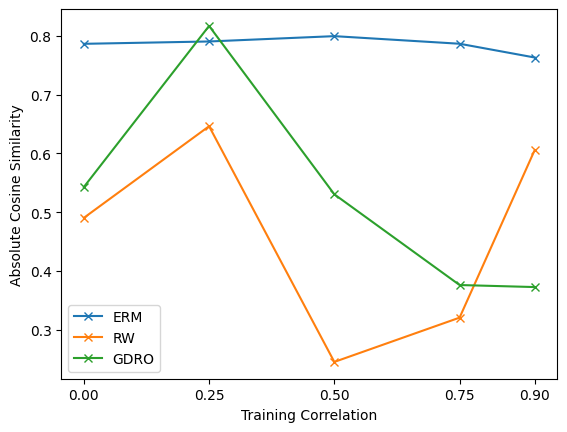

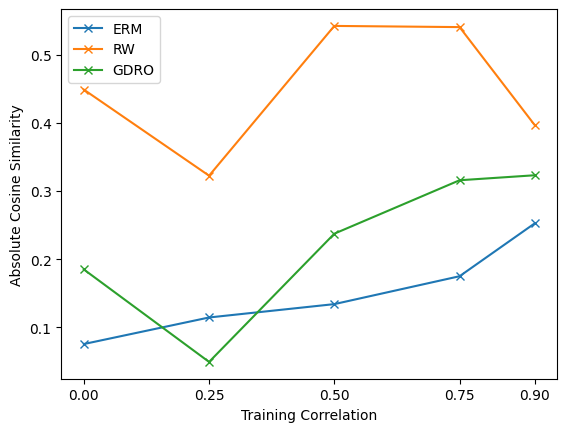

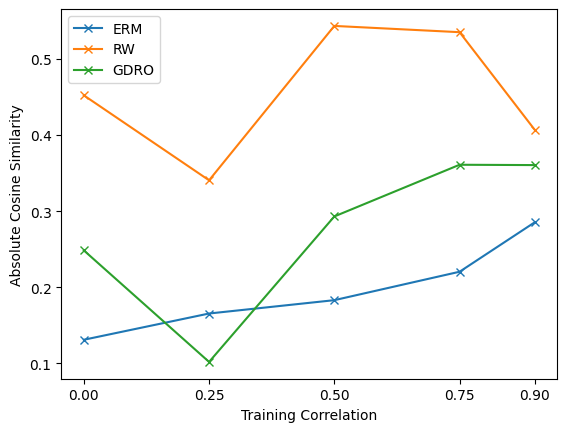

In [32]:

for dim in [0,1]:
    for method in methods:
        r = df[(df['dim']==0) & (df['method']==method) & (df['cls']==dim)]
        y = r['sim'].abs()
        x = corrs
        plt.plot(x,y, marker="x", label=method.upper())
        plt.legend()
        plt.xlabel("Training Correlation")
        plt.ylabel("Absolute Cosine Similarity")
        plt.xticks(x)
    plt.show()
    
for dim in [0,1]:
    for method in methods:
        r = df[(df['dim']==1) & (df['method']==method) & (df['cls']==dim)]
        y = r['sim'].abs()
        x = corrs
        plt.plot(x,y, marker="x", label=method.upper())
        plt.legend()
        plt.xlabel("Training Correlation")
        plt.ylabel("Absolute Cosine Similarity")
        plt.xticks(x)
    plt.show()

In [28]:
y

0   -0.798253
Name: sim, dtype: float64

0 0 100
0 1 100
0 2 100
1 0 100
1 1 100
1 2 100


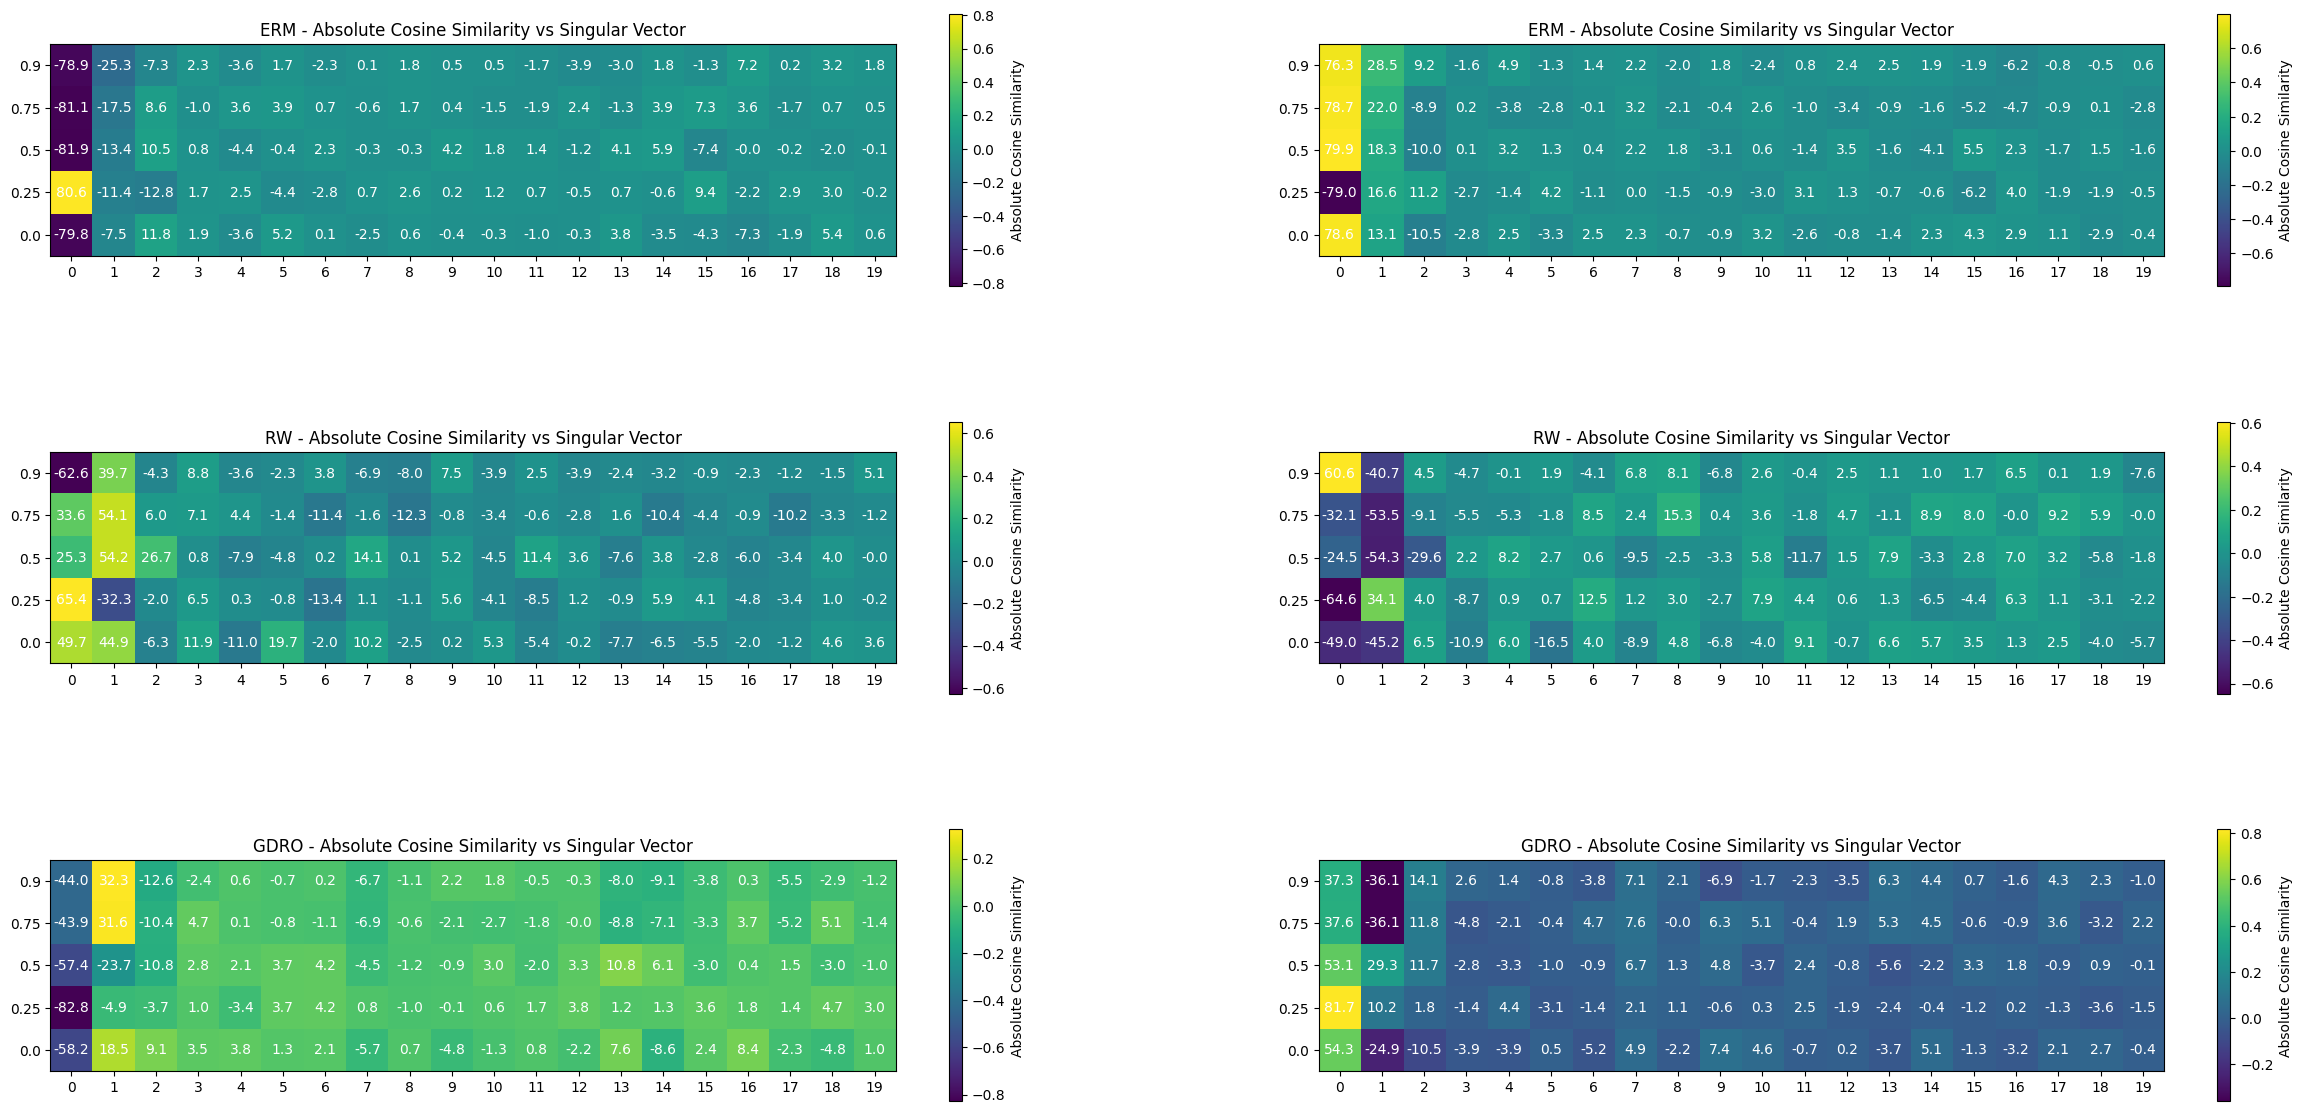

In [31]:
fig, axs = plt.subplots(figsize=(30,5*len(methods)), ncols=2, nrows=len(methods), sharey=False, sharex=False)
for j, c in enumerate([0,1]):
    for i, method in enumerate(methods):
        heatmap_data = df[(df['method']== method) & (df['cls'] == c)  & (df['dim']<20)]
        print(j,i, len(heatmap_data))
        heatmap_data = heatmap_data.pivot("corr","dim","sim")
        im = axs[i,j].imshow(heatmap_data, cmap='viridis', interpolation='nearest', origin='lower')
        # Add text annotations to the first subplot
        for k in range(len(heatmap_data.index)):
            for l in range(len(heatmap_data.columns)):
                axs[i,j].text(l, k, f'{100*heatmap_data.iloc[k, l]:.1f}', ha='center', va='center', color='white')
        axs[i, j].set_xticks(range(len(heatmap_data.columns)))
        axs[i, j].set_xticklabels(heatmap_data.columns)
        axs[i, j].set_yticks(range(len(heatmap_data.index)))
        axs[i, j].set_yticklabels(heatmap_data.index)
        axs[i, j].set_title(f"{method.upper()} - Absolute Cosine Similarity vs Singular Vector")
        fig.colorbar(im, ax=axs[i,j], label='Absolute Cosine Similarity', shrink=0.8)
plt.show()

In [41]:
len(df[(df['method']== method) & (df['cls'] == 1)  & (df['dim']<20)])

100

In [35]:
split_image(original_image, 3, 2,
            caption = f"spurious_accuracy_{dataset}",
            row_names=['erm',"reweight","gdro"], 
            column_names = ['train','test'],
            output_folder="imgs")

,method,corr,cls,dim,sim
0,erm,0.0,0,0,0.004928
1,erm,0.0,0,1,0.290713
2,erm,0.0,0,2,0.204964
3,erm,0.0,0,3,-0.026563
4,erm,0.0,0,4,0.019573
...,...,...,...,...,...
2995,gdro,0.9,1,95,-0.032089
2996,gdro,0.9,1,96,-0.034185
2997,gdro,0.9,1,97,-0.063075
2998,gdro,0.9,1,98,-0.044764
